# 📝 Week 3: Peringkasan Teks Artikel LPDP (Text Summarization)

Notebook ini mendemonstrasikan teknik **peringkasan teks otomatis** menggunakan metode **TF-IDF** pada artikel berita dari dataset **LPDP** yang ada di **Project A**.

## 📚 Tujuan Pembelajaran

1. Memuat dan mengeksplorasi dataset artikel LPDP dari Project A
2. Melakukan tokenisasi dan preprocessing teks berbahasa Indonesia
3. Menghapus stopword menggunakan Sastrawi
4. Menerapkan TF-IDF untuk menghitung bobot kata
5. Menghitung skor kalimat dan menentukan threshold
6. Menghasilkan ringkasan otomatis dari artikel LPDP
7. Memahami perhitungan manual TF-IDF untuk kata "beasiswa"

## 1) Import Library

In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd
import math

nltk.download('punkt_tab', quiet=True)

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 2) Muat Dataset LPDP dari Project A

Dataset berisi kumpulan **artikel berita tentang LPDP** yang dikumpulkan melalui proses scraping. Kita akan melihat struktur dataset dan memilih salah satu artikel untuk diringkas.

In [2]:
df_lpdp = pd.read_csv('../Project A/dataset_lpdp_sorted.csv')

print('📌 INFO DATASET LPDP:')
print('=' * 80)
print(f'  🔹 Jumlah baris   : {len(df_lpdp)}')
print(f'  🔹 Jumlah kolom   : {len(df_lpdp.columns)}')
print(f'  🔹 Nama kolom     : {list(df_lpdp.columns)}')
print('-' * 80)
print('\n📌 5 DATA PERTAMA:')
df_lpdp.head()

📌 INFO DATASET LPDP:
  🔹 Jumlah baris   : 1937
  🔹 Jumlah kolom   : 6
  🔹 Nama kolom     : ['Judul', 'Tanggal_Rilis', 'Deskripsi', 'URL_Artikel', 'Sumber_Media', 'Tanggal_Parsed']
--------------------------------------------------------------------------------

📌 5 DATA PERTAMA:


,Judul,Tanggal_Rilis,Deskripsi,URL_Artikel,Sumber_Media,Tanggal_Parsed
0,Video Pandangan Cinta Laura soal Siapa yang La...,"Mon, 02 Mar 2026 19:47:00 GMT",Video Pandangan Cinta Laura soal Siapa yang La...,https://news.google.com/rss/articles/CBMiswFBV...,20detik,2026-03-02 19:47:00
1,Video: Bukan Warga Inggris! Ditjen AHU Sebut A...,"Fri, 27 Feb 2026 10:15:00 GMT",Video: Bukan Warga Inggris! Ditjen AHU Sebut A...,https://news.google.com/rss/articles/CBMixgFBV...,20detik,2026-02-27 10:15:00
2,Video Dirjen AHU: Alumni LPDP 'Cukup Aku WNI' ...,"Thu, 26 Feb 2026 17:06:00 GMT",Video Dirjen AHU: Alumni LPDP 'Cukup Aku WNI' ...,https://news.google.com/rss/articles/CBMiwgFBV...,20detik,2026-02-26 17:06:00
3,Video: LPDP Masih Hitung Dana Pengembalian Bea...,"Thu, 26 Feb 2026 12:08:00 GMT",Video: LPDP Masih Hitung Dana Pengembalian Bea...,https://news.google.com/rss/articles/CBMiwwFBV...,20detik,2026-02-26 12:08:00
4,Video: Alyssa Soebandono Bantah Jadi Penerima ...,"Wed, 25 Feb 2026 09:34:00 GMT",Video: Alyssa Soebandono Bantah Jadi Penerima ...,https://news.google.com/rss/articles/CBMirwFBV...,20detik,2026-02-25 09:34:00


## 3) Definisi Dokumen (Artikel LPDP)

Karena dataset hanya berisi **Judul** dan **Deskripsi** singkat, kita akan menggunakan salah satu artikel berita LPDP yang relevan tentang **pembukaan beasiswa LPDP dan jenis-jenisnya**.

In [3]:
# Menampilkan contoh judul artikel dari dataset
print('📌 CONTOH JUDUL ARTIKEL LPDP DALAM DATASET:')
print('=' * 80)
for i, judul in enumerate(df_lpdp['Judul'].head(10)):
    print(f'  {i + 1}. {judul}')
print('=' * 80)

# Artikel LPDP yang akan digunakan untuk peringkasan
document = """Jakarta - Lembaga Pengelola Dana Pendidikan (LPDP) kembali membuka pendaftaran beasiswa untuk tahun 2024. Program beasiswa yang dikelola oleh Kementerian Keuangan ini menawarkan empat jenis beasiswa utama yang dapat dimanfaatkan oleh putra-putri terbaik bangsa untuk melanjutkan pendidikan ke jenjang yang lebih tinggi.

Keempat jenis beasiswa yang ditawarkan meliputi Beasiswa Reguler, Beasiswa Targeted, Beasiswa Afirmasi, dan Beasiswa Kolaborasi. Masing-masing program memiliki persyaratan dan fokus yang berbeda sesuai dengan kebutuhan pembangunan sumber daya manusia Indonesia.

Beasiswa Reguler ditujukan bagi masyarakat umum yang memenuhi persyaratan akademik dan non-akademik. Program ini mencakup pendanaan untuk studi magister dan doktoral, baik di perguruan tinggi dalam negeri maupun luar negeri yang masuk dalam daftar perguruan tinggi tujuan LPDP.

Sementara itu, Beasiswa Targeted dirancang khusus untuk memenuhi kebutuhan sumber daya manusia di sektor-sektor prioritas pembangunan nasional. Sektor-sektor tersebut meliputi pendidikan, kesehatan, infrastruktur, dan teknologi informasi yang menjadi tulang punggung kemajuan bangsa.

Beasiswa Afirmasi diberikan kepada kelompok masyarakat yang membutuhkan dukungan khusus dalam mengakses pendidikan tinggi. Kelompok ini mencakup putra-putri daerah tertinggal, terdepan, dan terluar (3T), penyandang disabilitas, serta masyarakat dari keluarga kurang mampu.

Beasiswa Kolaborasi merupakan program kemitraan antara LPDP dengan berbagai institusi, baik pemerintah maupun swasta, untuk mendanai pendidikan di bidang-bidang strategis tertentu.

Direktur Utama LPDP Andin Hadiyanto menyatakan bahwa program beasiswa ini merupakan investasi jangka panjang pemerintah dalam membangun sumber daya manusia yang unggul dan berdaya saing global. \"LPDP berkomitmen untuk terus meningkatkan kualitas program beasiswa agar dapat menghasilkan lulusan yang mampu berkontribusi nyata bagi kemajuan bangsa dan negara,\" ujar Andin dalam konferensi pers di Jakarta.

Sejak didirikan pada tahun 2012, LPDP telah memberikan beasiswa kepada lebih dari 35.000 penerima yang tersebar di berbagai perguruan tinggi terkemuka di dalam dan luar negeri. Para alumni LPDP telah berkontribusi di berbagai sektor pembangunan, mulai dari pendidikan, riset, pemerintahan, hingga dunia usaha.

Pendaftaran beasiswa LPDP untuk tahun 2024 dibuka secara daring melalui portal resmi beasiswalpdp.kemenkeu.go.id. Calon pendaftar diharapkan mempersiapkan dokumen yang diperlukan termasuk transkrip nilai, surat rekomendasi, dan esai rencana studi.

LPDP juga mengingatkan para calon pendaftar untuk memperhatikan batas waktu pendaftaran dan memastikan seluruh persyaratan terpenuhi sebelum mengirimkan berkas lamaran. Proses seleksi akan dilakukan secara bertahap mulai dari seleksi administrasi, tes substansi, hingga wawancara."""

print('\n📌 ARTIKEL LPDP YANG AKAN DIRINGKAS:')
print('=' * 80)
print(document.strip())
print('=' * 80)
print(f'📊 Panjang dokumen: {len(document.split())} kata')

📌 CONTOH JUDUL ARTIKEL LPDP DALAM DATASET:
  1. Video Pandangan Cinta Laura soal Siapa yang Layak Terima LPDP - 20detik
  2. Video: Bukan Warga Inggris! Ditjen AHU Sebut Anak Alumni LPDP Viral Masih WNI - 20detik
  3. Video Dirjen AHU: Alumni LPDP 'Cukup Aku WNI' Langgar Hak Perlindungan Anak - 20detik
  4. Video: LPDP Masih Hitung Dana Pengembalian Beasiswa Suami DS 'Cukup Aku WNI' - 20detik
  5. Video: Alyssa Soebandono Bantah Jadi Penerima Beasiswa LPDP - 20detik
  6. Video: Buntut Panjang Ucapan Eks Awardee LPDP 'Cukup Aku WNI' - 20detik
  7. Video K-Talk: Kuliah di Korea Gak Cuma Pakai GKS atau LPDP, Caranya? - 20detik
  8. Video: Heboh Kasus LPDP 'Cukup Saya WNI, Anak Jangan' Berujung Minta Maaf - 20detik
  9. Video: Akhir Tragis Panglima OPM, Lamek Taplo Gugur di Tangan TNI - 20detik
  10. Video: Kepala Sekolah Tampar Siswa Merokok, Murid Lakukan Aksi Mogok - 20detik

📌 ARTIKEL LPDP YANG AKAN DIRINGKAS:
Jakarta - Lembaga Pengelola Dana Pendidikan (LPDP) kembali membuka pendaftar

## 4) Tokenisasi Kalimat

Dokumen akan dipecah menjadi kalimat-kalimat menggunakan `sent_tokenize` dari NLTK.

In [4]:
sent_tokens = sent_tokenize(document)

print('📌 HASIL TOKENISASI KALIMAT:')
print('=' * 80)
for i, sent in enumerate(sent_tokens):
    print(f'  Kalimat {i + 1}: {sent}')
    print('-' * 80)
print(f'\n📊 Jumlah kalimat: {len(sent_tokens)}')

📌 HASIL TOKENISASI KALIMAT:
  Kalimat 1: Jakarta - Lembaga Pengelola Dana Pendidikan (LPDP) kembali membuka pendaftaran beasiswa untuk tahun 2024.
--------------------------------------------------------------------------------
  Kalimat 2: Program beasiswa yang dikelola oleh Kementerian Keuangan ini menawarkan empat jenis beasiswa utama yang dapat dimanfaatkan oleh putra-putri terbaik bangsa untuk melanjutkan pendidikan ke jenjang yang lebih tinggi.
--------------------------------------------------------------------------------
  Kalimat 3: Keempat jenis beasiswa yang ditawarkan meliputi Beasiswa Reguler, Beasiswa Targeted, Beasiswa Afirmasi, dan Beasiswa Kolaborasi.
--------------------------------------------------------------------------------
  Kalimat 4: Masing-masing program memiliki persyaratan dan fokus yang berbeda sesuai dengan kebutuhan pembangunan sumber daya manusia Indonesia.
--------------------------------------------------------------------------------
  Kalimat 5: B

## 5) Hapus Stopword dengan Sastrawi

Stopword bahasa Indonesia akan dihapus menggunakan library **Sastrawi** agar TF-IDF lebih fokus pada kata-kata bermakna.

In [5]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_tokens]

print('📌 KALIMAT SETELAH HAPUS STOPWORD:')
print('=' * 80)
for i, (original, cleaned) in enumerate(zip(sent_tokens, cleaned_sentences)):
    print(f'  Kalimat {i + 1}:')
    print(f'    🔹 Asli    : {original[:100]}...')
    print(f'    🔹 Bersih  : {cleaned[:100]}...')
    print('-' * 80)

print(f'\n✅ Stopword berhasil dihapus dari {len(cleaned_sentences)} kalimat')

📌 KALIMAT SETELAH HAPUS STOPWORD:
  Kalimat 1:
    🔹 Asli    : Jakarta - Lembaga Pengelola Dana Pendidikan (LPDP) kembali membuka pendaftaran beasiswa untuk tahun ...
    🔹 Bersih  : Jakarta - Lembaga Pengelola Dana Pendidikan (LPDP) membuka pendaftaran beasiswa tahun 2024....
--------------------------------------------------------------------------------
  Kalimat 2:
    🔹 Asli    : Program beasiswa yang dikelola oleh Kementerian Keuangan ini menawarkan empat jenis beasiswa utama y...
    🔹 Bersih  : Program beasiswa dikelola Kementerian Keuangan menawarkan empat jenis beasiswa utama dapat dimanfaat...
--------------------------------------------------------------------------------
  Kalimat 3:
    🔹 Asli    : Keempat jenis beasiswa yang ditawarkan meliputi Beasiswa Reguler, Beasiswa Targeted, Beasiswa Afirma...
    🔹 Bersih  : Keempat jenis beasiswa ditawarkan meliputi Beasiswa Reguler, Beasiswa Targeted, Beasiswa Afirmasi, B...
------------------------------------------------------

## 6) Vektorisasi TF-IDF

Setiap kalimat yang sudah bersih akan diubah menjadi vektor TF-IDF.

In [6]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(cleaned_sentences)

feature_names = vectorizer.get_feature_names_out()

print('✅ TF-IDF Vectorizer berhasil dilatih!')
print(f'📊 Ukuran matriks TF-IDF: {tfidf_matrix.shape}')
print(f'   - Jumlah kalimat  : {tfidf_matrix.shape[0]}')
print(f'   - Jumlah kata unik: {tfidf_matrix.shape[1]}')

print('\n📌 Contoh fitur (kata) dalam vocabulary:')
print(feature_names[:20])

✅ TF-IDF Vectorizer berhasil dilatih!
📊 Ukuran matriks TF-IDF: (19, 190)
   - Jumlah kalimat  : 19
   - Jumlah kata unik: 190

📌 Contoh fitur (kata) dalam vocabulary:
['000' '2012' '2024' '35' '3t' 'administrasi' 'afirmasi' 'akademik'
 'alumni' 'andin' 'baik' 'bangsa' 'batas' 'beasiswa' 'beasiswalpdp'
 'berbagai' 'berbeda' 'berdaya' 'berkas' 'berkomitmen']


📌 NILAI TF-IDF KALIMAT PERTAMA (setelah hapus stopword):
       Kata   TF-IDF
       dana 0.361669
    membuka 0.361669
    lembaga 0.361669
  pengelola 0.361669
       2024 0.317267
    jakarta 0.317267
      tahun 0.285762
pendaftaran 0.285762
 pendidikan 0.224478
       lpdp 0.185418
   beasiswa 0.165452


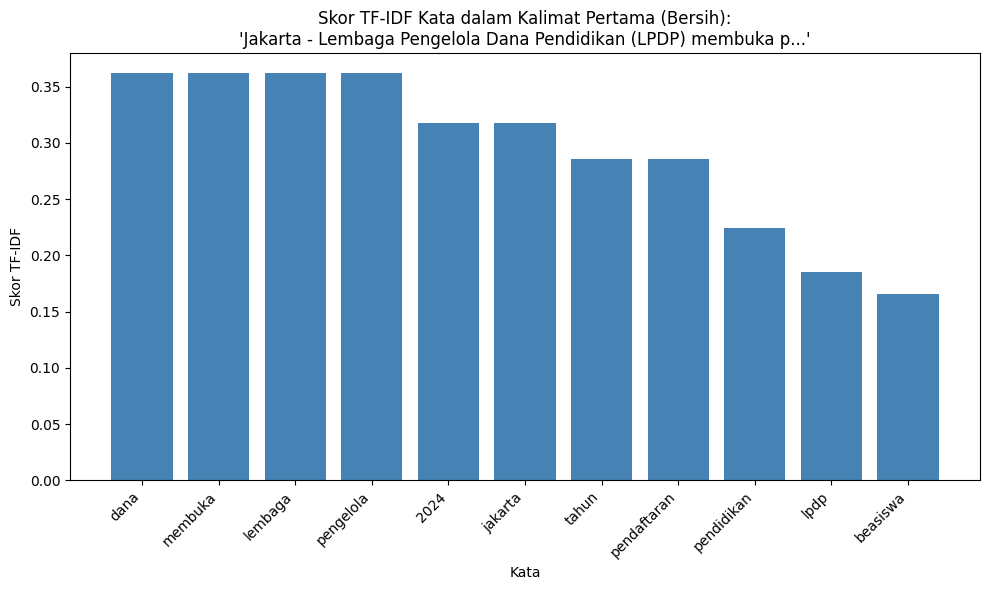

In [7]:
# Menampilkan TF-IDF untuk kalimat pertama
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    """Mengembalikan DataFrame TF-IDF untuk kalimat tertentu."""
    values = tfidf_matrix[sentence_index].toarray().flatten()
    df = pd.DataFrame({'Kata': feature_names, 'TF-IDF': values})
    df = df[df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return df

df_first = get_tfidf_for_sentence(tfidf_matrix, 0, feature_names)

print('📌 NILAI TF-IDF KALIMAT PERTAMA (setelah hapus stopword):')
print('=' * 80)
print(df_first.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 6))
plt.bar(df_first['Kata'], df_first['TF-IDF'], color='steelblue')
plt.xlabel('Kata')
plt.ylabel('Skor TF-IDF')
plt.title(f"Skor TF-IDF Kata dalam Kalimat Pertama (Bersih):\n'{cleaned_sentences[0][:60]}...'")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7) Hitung Skor Kalimat

Skor setiap kalimat dihitung dari **rata-rata nilai TF-IDF** kata-kata yang ada di dalamnya.

📌 SKOR RATA-RATA TF-IDF SETIAP KALIMAT:
  Kalimat 1:
    🔹 Jumlah TF-IDF  : 3.2281
    🔹 Jumlah kata     : 11
    🔹 Skor rata-rata  : 0.2935
--------------------------------------------------------------------------------
  Kalimat 2:
    🔹 Jumlah TF-IDF  : 4.4320
    🔹 Jumlah kata     : 20
    🔹 Skor rata-rata  : 0.2216
--------------------------------------------------------------------------------
  Kalimat 3:
    🔹 Jumlah TF-IDF  : 2.7746
    🔹 Jumlah kata     : 9
    🔹 Skor rata-rata  : 0.3083
--------------------------------------------------------------------------------
  Kalimat 4:
    🔹 Jumlah TF-IDF  : 3.4165
    🔹 Jumlah kata     : 13
    🔹 Skor rata-rata  : 0.2628
--------------------------------------------------------------------------------
  Kalimat 5:
    🔹 Jumlah TF-IDF  : 2.7808
    🔹 Jumlah kata     : 9
    🔹 Skor rata-rata  : 0.3090
--------------------------------------------------------------------------------
  Kalimat 6:
    🔹 Jumlah TF-IDF  : 3.8054
    🔹 Jum

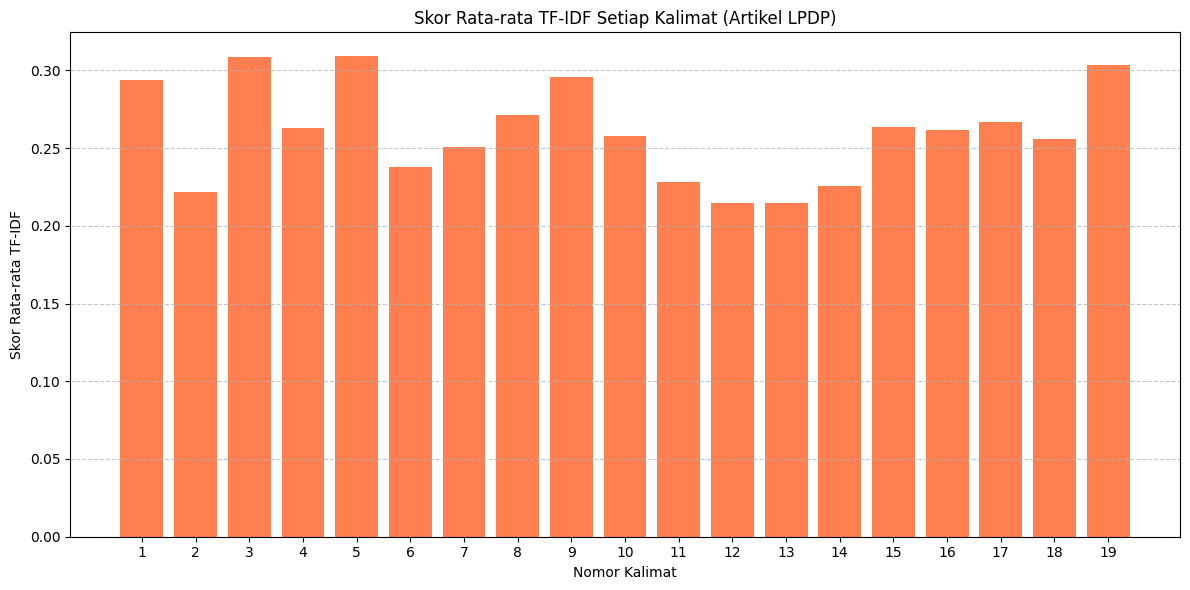


📌 PENJELASAN HISTOGRAM:
  - Bar yang lebih tinggi = kalimat mengandung kata yang lebih penting dan unik dalam artikel
  - Bar yang lebih rendah = kalimat mengandung kata yang lebih umum di seluruh artikel
  - Dengan melihat histogram, kita bisa mengetahui kalimat mana yang paling informatif


In [8]:
sent_scores = []

print('📌 SKOR RATA-RATA TF-IDF SETIAP KALIMAT:')
print('=' * 80)

for idx, row in enumerate(tfidf_matrix):
    total_score = row.sum()
    num_words = len(row.data)
    avg_score = total_score / num_words if num_words > 0 else 0
    sent_scores.append(avg_score)
    print(f'  Kalimat {idx + 1}:')
    print(f'    🔹 Jumlah TF-IDF  : {total_score:.4f}')
    print(f'    🔹 Jumlah kata     : {num_words}')
    print(f'    🔹 Skor rata-rata  : {avg_score:.4f}')
    print('-' * 80)

# Visualisasi skor kalimat
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores, color='coral')
plt.xlabel('Nomor Kalimat')
plt.ylabel('Skor Rata-rata TF-IDF')
plt.title('Skor Rata-rata TF-IDF Setiap Kalimat (Artikel LPDP)')
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\n📌 PENJELASAN HISTOGRAM:')
print('  - Bar yang lebih tinggi = kalimat mengandung kata yang lebih penting dan unik dalam artikel')
print('  - Bar yang lebih rendah = kalimat mengandung kata yang lebih umum di seluruh artikel')
print('  - Dengan melihat histogram, kita bisa mengetahui kalimat mana yang paling informatif')

## 8) Tentukan Threshold & Buat Ringkasan

Threshold dihitung dari rata-rata seluruh skor kalimat. Kalimat yang skornya di atas threshold akan masuk ke ringkasan.

In [9]:
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f'📌 THRESHOLD (Rata-rata Skor Kalimat): {threshold:.4f}')
print('=' * 80)

# Pilih kalimat yang skornya di atas threshold
summary_sentences = []
print('\n📌 KALIMAT YANG LOLOS THRESHOLD:')
print('-' * 80)
for idx, (score, sent) in enumerate(zip(sent_scores, sent_tokens)):
    if score >= threshold:
        summary_sentences.append(sent)
        print(f'  ✅ Kalimat {idx + 1} (skor: {score:.4f}): {sent[:80]}...')

print('\n' + '=' * 80)
print('📌 HASIL RINGKASAN ARTIKEL LPDP:')
print('=' * 80)
summary = ' '.join(summary_sentences)
print(summary)
print('=' * 80)
print(f'\n📊 Jumlah kalimat asli    : {len(sent_tokens)}')
print(f'📊 Jumlah kalimat ringkasan: {len(summary_sentences)}')
print(f'📊 Rasio kompresi          : {len(summary_sentences)/len(sent_tokens)*100:.1f}%')

📌 THRESHOLD (Rata-rata Skor Kalimat): 0.2601

📌 KALIMAT YANG LOLOS THRESHOLD:
--------------------------------------------------------------------------------
  ✅ Kalimat 1 (skor: 0.2935): Jakarta - Lembaga Pengelola Dana Pendidikan (LPDP) kembali membuka pendaftaran b...
  ✅ Kalimat 3 (skor: 0.3083): Keempat jenis beasiswa yang ditawarkan meliputi Beasiswa Reguler, Beasiswa Targe...
  ✅ Kalimat 4 (skor: 0.2628): Masing-masing program memiliki persyaratan dan fokus yang berbeda sesuai dengan ...
  ✅ Kalimat 5 (skor: 0.3090): Beasiswa Reguler ditujukan bagi masyarakat umum yang memenuhi persyaratan akadem...
  ✅ Kalimat 8 (skor: 0.2714): Sektor-sektor tersebut meliputi pendidikan, kesehatan, infrastruktur, dan teknol...
  ✅ Kalimat 9 (skor: 0.2955): Beasiswa Afirmasi diberikan kepada kelompok masyarakat yang membutuhkan dukungan...
  ✅ Kalimat 15 (skor: 0.2634): Para alumni LPDP telah berkontribusi di berbagai sektor pembangunan, mulai dari ...
  ✅ Kalimat 16 (skor: 0.2619): Pendaftaran

## 9) Perhitungan Manual TF-IDF

Pada bagian ini, kita akan menghitung **TF-IDF secara manual** untuk kata **"beasiswa"** di setiap kalimat, untuk memahami cara kerja TF-IDF secara lebih mendalam.

In [11]:
# Fungsi untuk menghitung TF (Term Frequency)
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Fungsi untuk menghitung IDF (Inverse Document Frequency)
def calculate_idf(term, all_documents):
    num_docs_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_docs_with_term > 0:
        return math.log(len(all_documents) / num_docs_with_term)
    else:
        return 0

# Hitung TF-IDF manual untuk kata "beasiswa"
target_word = 'beasiswa'

print(f'📌 PERHITUNGAN MANUAL TF-IDF UNTUK KATA "{target_word}":')
print('=' * 80)

tfidf_scores = {}
for i, sent in enumerate(sent_tokens):
    cleaned = stopword_remover.remove(sent)
    tf = calculate_tf(target_word, cleaned)
    idf = calculate_idf(target_word, cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f'Kalimat {i + 1}'] = tfidf
    if tfidf > 0:
        print(f'  🔹 Kalimat {i + 1}: TF={tf:.4f} × IDF={idf:.4f} = TF-IDF={tfidf:.4f}')

# IDF keseluruhan
overall_idf = calculate_idf(target_word, cleaned_sentences)
print(f'\n📊 IDF keseluruhan untuk "{target_word}": {overall_idf:.4f}')

print('\n📌 SEMUA SKOR TF-IDF:')
print('-' * 80)
for sent_num, score in tfidf_scores.items():
    print(f'  {sent_num}: {score:.4f}')

📌 PERHITUNGAN MANUAL TF-IDF UNTUK KATA "beasiswa":
  🔹 Kalimat 1: TF=0.0667 × IDF=0.5465 = TF-IDF=0.0364
  🔹 Kalimat 2: TF=0.0952 × IDF=0.5465 = TF-IDF=0.0521
  🔹 Kalimat 3: TF=0.2941 × IDF=0.5465 = TF-IDF=0.1607
  🔹 Kalimat 5: TF=0.1000 × IDF=0.5465 = TF-IDF=0.0547
  🔹 Kalimat 7: TF=0.0588 × IDF=0.5465 = TF-IDF=0.0321
  🔹 Kalimat 9: TF=0.0833 × IDF=0.5465 = TF-IDF=0.0455
  🔹 Kalimat 11: TF=0.0500 × IDF=0.5465 = TF-IDF=0.0273
  🔹 Kalimat 12: TF=0.0455 × IDF=0.5465 = TF-IDF=0.0248
  🔹 Kalimat 13: TF=0.0400 × IDF=0.5465 = TF-IDF=0.0219
  🔹 Kalimat 14: TF=0.0500 × IDF=0.5465 = TF-IDF=0.0273
  🔹 Kalimat 16: TF=0.0833 × IDF=0.5465 = TF-IDF=0.0455

📊 IDF keseluruhan untuk "beasiswa": 0.5465

📌 SEMUA SKOR TF-IDF:
--------------------------------------------------------------------------------
  Kalimat 1: 0.0364
  Kalimat 2: 0.0521
  Kalimat 3: 0.1607
  Kalimat 4: 0.0000
  Kalimat 5: 0.0547
  Kalimat 6: 0.0000
  Kalimat 7: 0.0321
  Kalimat 8: 0.0000
  Kalimat 9: 0.0455
  Kalimat 10: 0.0000
  

## ✅ Kesimpulan

Pada notebook ini, kita telah berhasil:
1. Memuat dan mengeksplorasi **dataset LPDP** dari Project A
2. Melakukan **tokenisasi kalimat** pada artikel berita LPDP
3. Menghapus **stopword** menggunakan **Sastrawi**
4. Menerapkan **TF-IDF** untuk menghitung bobot kata dalam kalimat
5. Menghitung **skor kalimat** berdasarkan rata-rata TF-IDF dan memvisualisasikannya
6. Menentukan **threshold** dan menghasilkan **ringkasan** otomatis dari artikel LPDP
7. Memahami **perhitungan manual TF-IDF** untuk kata "beasiswa"

Artikel LPDP yang digunakan berkaitan dengan topik yang ada di dataset Project A, yaitu tentang program **beasiswa LPDP** dan jenis-jenisnya.